# 12b · Kaplan-Meier at NP1PAIN ≥ 2 (relaxed threshold)

Notebook 12 used ≥ 3 (severe+); too strict — only 48 events in 170 patients. Here we use ≥ 2 (moderate+), which should raise event count and statistical power. Cox regression with same baseline covariates.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(survival); library(survminer) })
df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))

THRESHOLD <- 2
post <- df %>% dplyr::filter(time_pos >= 0, !is.na(NP1PAIN))
pre_high <- df %>% dplyr::filter(time_pos < 0, !is.na(NP1PAIN), NP1PAIN >= THRESHOLD) %>%
  dplyr::distinct(PATNO) %>% dplyr::pull(PATNO)
post <- post %>% dplyr::filter(!PATNO %in% pre_high)
cat("After excluding pre-anchor NP1PAIN≥", THRESHOLD, ":",
    dplyr::n_distinct(post$PATNO), "patients\n")

Warning message:
“package ‘survminer’ was built under R version 4.5.2”


After excluding pre-anchor NP1PAIN≥ 2 : 170 patients


In [2]:
ev <- post %>% dplyr::arrange(PATNO, time_pos_months) %>%
  dplyr::group_by(PATNO, will_receive_dbs) %>%
  dplyr::summarise(
    event_time = { hi <- which(NP1PAIN >= THRESHOLD);
      if (length(hi) > 0) time_pos_months[hi[1]] else max(time_pos_months, na.rm = TRUE) },
    event = as.integer(any(NP1PAIN >= THRESHOLD)),
    .groups = "drop"
  ) %>% dplyr::filter(is.finite(event_time), event_time > 0)
cat("Analytic n:", nrow(ev), "  events:", sum(ev$event), "\n")
print(dplyr::count(ev, will_receive_dbs, event))

fit <- survival::survfit(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev)
print(summary(fit, times = c(6, 12, 24, 36, 48, 60)))
lr <- survival::survdiff(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev)
print(lr)
cat("Log-rank p:", signif(1 - pchisq(lr$chisq, df = length(lr$n) - 1), 4), "\n")

Analytic n: 123   events: 66 


# A tibble: 4 × 3
  will_receive_dbs event     n
  <lgl>            <int> <int>
1 FALSE                0    41
2 FALSE                1    35
3 TRUE                 0    16
4 TRUE                 1    31


Call: survfit(formula = survival::Surv(event_time, event) ~ will_receive_dbs, 
    data = ev)

                will_receive_dbs=FALSE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    6     61      10    0.862  0.0405        0.786        0.945
   12     55       5    0.792  0.0480        0.703        0.891
   24     30      10    0.625  0.0609        0.516        0.756
   36     18       5    0.498  0.0703        0.378        0.657
   48     15       2    0.441  0.0729        0.319        0.610
   60      6       2    0.382  0.0741        0.261        0.559

                will_receive_dbs=TRUE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    6     30      17    0.638  0.0701        0.515        0.792
   12     27       3    0.574  0.0721        0.449        0.735
   24     16       6    0.441  0.0733        0.318        0.611
   36     12       3    0.358  0.0735        0.240        0.536
   48     10       1    0.329  0.0732        0.212       

Call:
survival::survdiff(formula = survival::Surv(event_time, event) ~ 
    will_receive_dbs, data = ev)

                        N Observed Expected (O-E)^2/E (O-E)^2/V
will_receive_dbs=FALSE 76       35     41.9      1.13      3.18
will_receive_dbs=TRUE  47       31     24.1      1.96      3.18

 Chisq= 3.2  on 1 degrees of freedom, p= 0.07 


Log-rank p: 0.07464 


Ignoring unknown labels:
• colour : "Strata"


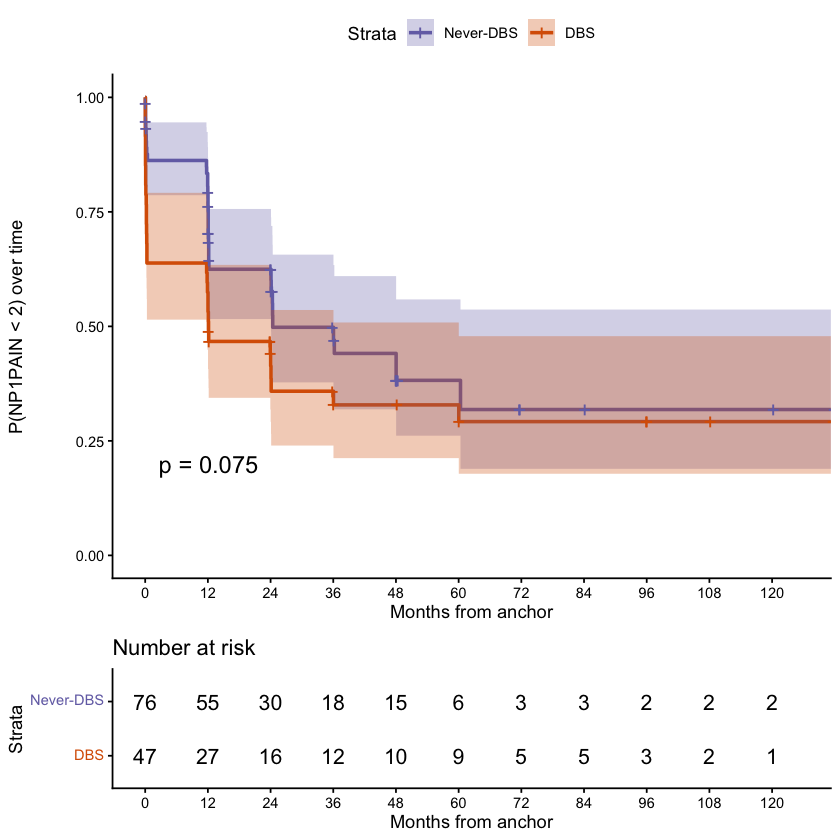

In [3]:
p_km <- survminer::ggsurvplot(
  fit, data = ev,
  palette = c("#7570b3", "#d95f02"),
  legend.labs = c("Never-DBS", "DBS"),
  xlab = "Months from anchor",
  ylab = sprintf("P(NP1PAIN < %d) over time", THRESHOLD),
  risk.table = TRUE, break.x.by = 12, pval = TRUE, conf.int = TRUE,
  ggtheme = theme_classic(base_size = 11)
)
print(p_km)
ggplot2::ggsave(file.path(OUT_FIG, "Fig20b_km_threshold_2.png"),
                plot = p_km$plot, width = 7.5, height = 5, dpi = 300)

In [4]:
base <- df %>% dplyr::arrange(PATNO, INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, age_at_visit, SEX, LEDD, updrs3_score, NP1PAIN, NP1DPRS, NP1ANXS)
ev2 <- ev %>% dplyr::inner_join(base, by = "PATNO") %>% tidyr::drop_na()
cat("Cox n:", nrow(ev2), "\n")
cox <- survival::coxph(
  survival::Surv(event_time, event) ~ will_receive_dbs + age_at_visit + SEX +
    LEDD + updrs3_score + NP1PAIN + NP1DPRS + NP1ANXS,
  data = ev2
)
print(summary(cox))
tbl <- broom::tidy(cox, conf.int = TRUE, exponentiate = TRUE)
print(tbl)
save_table(tbl, "cox_pain_thr2")
save_object(ev, "km_event_table_thr2")

Cox n: 102 


Call:
survival::coxph(formula = survival::Surv(event_time, event) ~ 
    will_receive_dbs + age_at_visit + SEX + LEDD + updrs3_score + 
        NP1PAIN + NP1DPRS + NP1ANXS, data = ev2)

  n= 102, number of events= 58 

                           coef  exp(coef)   se(coef)      z Pr(>|z|)  
will_receive_dbsTRUE  0.7070829  2.0280666  0.2979244  2.373   0.0176 *
age_at_visit         -0.0118253  0.9882443  0.0173343 -0.682   0.4951  
SEX                   0.1137018  1.1204180  0.2806334  0.405   0.6854  
LEDD                 -0.0011069  0.9988937  0.0006182 -1.790   0.0734 .
updrs3_score         -0.0181694  0.9819947  0.0146192 -1.243   0.2139  
NP1PAIN               0.3892267  1.4758391  0.1982999  1.963   0.0497 *
NP1DPRS               0.2290949  1.2574613  0.3133363  0.731   0.4647  
NP1ANXS              -0.1863944  0.8299462  0.2765944 -0.674   0.5004  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                     exp(coef) exp(-coef) lower .95 upper .95
wil

# A tibble: 8 × 7
  term                 estimate std.error statistic p.value conf.low conf.high
  <chr>                   <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 will_receive_dbsTRUE    2.03   0.298        2.37   0.0176    1.13       3.64
2 age_at_visit            0.988  0.0173      -0.682  0.495     0.955      1.02
3 SEX                     1.12   0.281        0.405  0.685     0.646      1.94
4 LEDD                    0.999  0.000618    -1.79   0.0734    0.998      1.00
5 updrs3_score            0.982  0.0146      -1.24   0.214     0.954      1.01
6 NP1PAIN                 1.48   0.198        1.96   0.0497    1.00       2.18
7 NP1DPRS                 1.26   0.313        0.731  0.465     0.680      2.32
8 NP1ANXS                 0.830  0.277       -0.674  0.500     0.483      1.43
